Selected lambda: 2.0
Treatment start: 2011-04-01
Derived trperiod: 424
Complete-case states: 46
Donor count: 45
Predictor count: 13
Pre-period length: 27

=== FULL SAMPLE TOPOLOGY-AUGMENTED REFERENCE ===
pre_rmspe             0.128232
post_rmspe            0.719162
post_pre_ratio         5.60828
h1_wasserstein_31     0.646785
max_weight            0.216985
top_weight_donor     MINNESOTA

Top donors in full-sample topology-augmented solution:
MINNESOTA       0.216985
ARIZONA         0.164710
KENTUCKY        0.159066
CALIFORNIA      0.133505
IDAHO           0.071019
MONTANA         0.039053
NORTH DAKOTA    0.037921
NEVADA          0.031554
CONNECTICUT     0.022287
MARYLAND        0.021088
dtype: float64

Scenarios to run:
 - full_sample
 - drop_top_1_MINNESOTA
 - drop_top_2_ARIZONA
 - drop_top_3_KENTUCKY
[FAILED] drop_top_2_ARIZONA: Topology-augmented optimization failed for all starts.

=== LOO SUMMARY ===
            scenario removed_donor  donor_rank_in_full_solution  lambda  n_donors

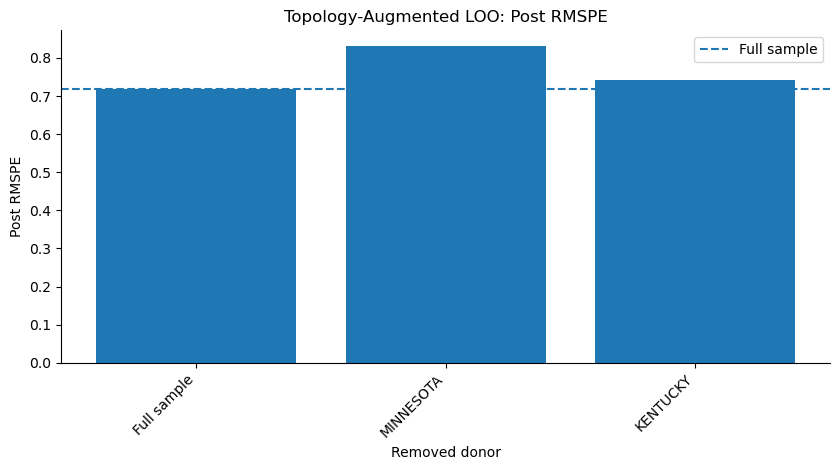

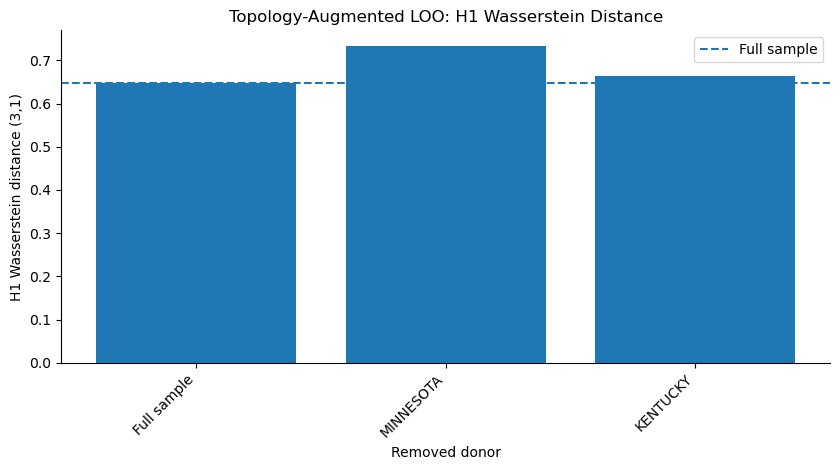

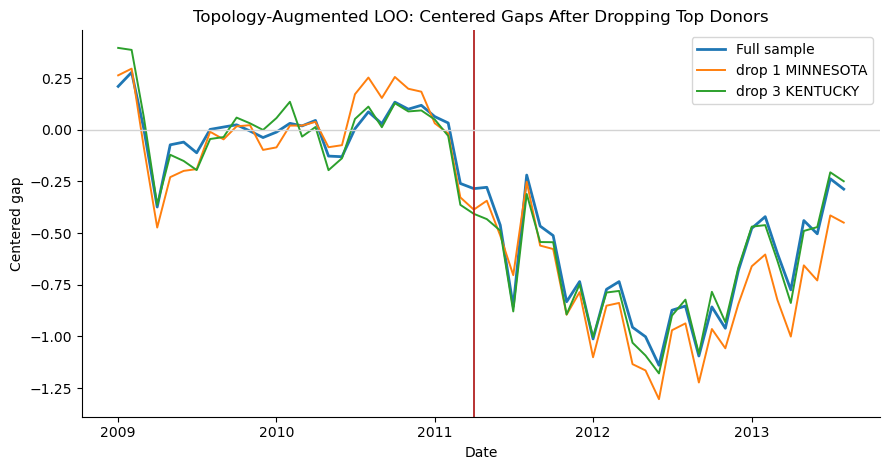


Saved outputs in: /home/jupyter/topological fit check on scm/outputs_topology_augmented_loo
 - drop_top_1_MINNESOTA_paths.csv
 - drop_top_1_MINNESOTA_weights.csv
 - drop_top_3_KENTUCKY_paths.csv
 - drop_top_3_KENTUCKY_weights.csv
 - topology_augmented_loo_centered_gaps_top_donor_drops.pdf
 - topology_augmented_loo_decision_summary.csv
 - topology_augmented_loo_decision_summary.txt
 - topology_augmented_loo_failed_runs.csv
 - topology_augmented_loo_full_sample_paths.csv
 - topology_augmented_loo_full_sample_weights.csv
 - topology_augmented_loo_h1_wasserstein.pdf
 - topology_augmented_loo_post_rmspe.pdf
 - topology_augmented_loo_summary.csv
 - topology_augmented_loo_summary.txt


In [2]:
# ============================================================
# 10_topology_augmented_loo.ipynb
# Revised version
#
# Purpose:
#   Leave-one-out robustness check for topology-augmented SCM
#
# Key revision:
#   1) Full-sample reference is anchored to file 06 selected weights
#   2) LOO runs use aligned selected weights as warm start
#
# Default:
#   - Full sample
#   - Drop top 1 donor
#   - Drop top 2 donor
#   - Drop top 3 donor
#
# Optional:
#   - Set RUN_ALL_DONOR_LOO = True to run every donor once
# ============================================================

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from ripser import ripser
from persim import wasserstein

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
ROOT = Path(".").resolve()

INPUT_DIR = ROOT / "outputs_baseline"
TOPO_DIR = ROOT / "outputs_topology_augmented"
OUTPUT_DIR = ROOT / "outputs_topology_augmented_loo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PATH = INPUT_DIR / "panel_df_with_unemp_s.csv"
SELECTED_LAMBDA_PATH = TOPO_DIR / "selected_lambda.json"
SELECTED_WEIGHTS_PATH = TOPO_DIR / "topology_augmented_selected_weights.csv"

# ------------------------------------------------------------
# 1) Settings
# ------------------------------------------------------------
TREATMENT_START = pd.Timestamp("2011-04-01")
TREATED_STATE = "MISSOURI"

DROP_STATES = {"FLORIDA", "ARKANSAS", "MICHIGAN", "SOUTH CAROLINA", "GEORGIA"}

ANCHOR_STATIC = 409
ANCHOR_UNEMP = [397, 401, 405, 409, 413, 417, 421]
STATIC_COLS = ["pct_rural", "Chg1999_2006", "Chg2007_2010", "p12", "p_naics3", "p_naics4"]

# Main topology specification used in file 06
EMBED_DIM = 3
EMBED_DELAY = 1

# Decisive version first
TOP_K_DONORS_TO_TEST = 3
RUN_ALL_DONOR_LOO = False

# Optimizer settings
W_MAXITER = 200
V_MAXITER = 120
FTOL = 1e-7
RANDOM_STARTS = 4
RNG_SEED = 123

# ------------------------------------------------------------
# 2) Helpers
# ------------------------------------------------------------
def load_series_csv(path):
    tmp = pd.read_csv(path)
    if tmp.shape[1] < 2:
        raise ValueError(f"Cannot parse series-like csv: {path}")
    idx = tmp.iloc[:, 0].astype(str)
    vals = pd.to_numeric(tmp.iloc[:, 1], errors="coerce")
    s = pd.Series(vals.values, index=idx.values)
    s = s.dropna()
    return s

def zscore(x):
    x = np.asarray(x, dtype=float)
    s = x.std(ddof=0)
    if s == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / s

def delay_embed(x, dim=3, delay=1):
    x = np.asarray(x, dtype=float)
    n = len(x) - (dim - 1) * delay
    if n <= 0:
        raise ValueError(f"Series too short: len={len(x)}, dim={dim}, delay={delay}")
    return np.column_stack([x[i * delay:i * delay + n] for i in range(dim)])

def h1_wasserstein_from_series(seq1, seq2, dim=3, delay=1):
    s1 = zscore(seq1)
    s2 = zscore(seq2)

    cloud1 = delay_embed(s1, dim=dim, delay=delay)
    cloud2 = delay_embed(s2, dim=dim, delay=delay)

    dgm1 = ripser(cloud1, maxdim=1)["dgms"][1]
    dgm2 = ripser(cloud2, maxdim=1)["dgms"][1]

    if len(dgm1) > 0:
        dgm1 = dgm1[np.isfinite(dgm1[:, 1])]
    if len(dgm2) > 0:
        dgm2 = dgm2[np.isfinite(dgm2[:, 1])]

    if len(dgm1) == 0 and len(dgm2) == 0:
        return 0.0

    return float(wasserstein(dgm1, dgm2))

def pre_rmspe(Z1, Z0, w):
    gap = Z1 - Z0 @ w
    return float(np.sqrt(np.mean(gap ** 2)))

def rmspe_from_series(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x ** 2)))

def simplex_random_start(J, rng):
    return np.asarray(rng.dirichlet(np.ones(J)), dtype=float)

# ------------------------------------------------------------
# 3) Baseline SCM optimizer
# ------------------------------------------------------------
def solve_w_given_v_np(X1, X0, v):
    V = np.diag(v)

    def obj(w):
        d = X1 - X0 @ w
        return float(d.T @ V @ d)

    J = X0.shape[1]
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * J
    w0 = np.repeat(1.0 / J, J)

    res = minimize(
        obj,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": W_MAXITER, "ftol": FTOL, "disp": False}
    )

    if not res.success:
        raise RuntimeError(f"W optimization failed: {res.message}")

    w_star = np.clip(res.x.copy(), 0.0, 1.0)
    w_star = w_star / w_star.sum()
    return w_star

def fit_synth_nested_np(X1, X0, Z1, Z0):
    K = X0.shape[0]

    def outer_obj(v_raw):
        v = np.maximum(v_raw, 1e-10)
        v = v / v.sum()
        w = solve_w_given_v_np(X1, X0, v)
        z_gap = Z1 - Z0 @ w
        return float(np.mean(z_gap ** 2))

    v0 = np.repeat(1.0 / K, K)
    cons = [{"type": "eq", "fun": lambda v: np.sum(v) - 1.0}]
    bounds = [(1e-10, 1.0)] * K

    res_v = minimize(
        outer_obj,
        v0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": V_MAXITER, "ftol": FTOL, "disp": False}
    )

    if not res_v.success:
        raise RuntimeError(f"V optimization failed: {res_v.message}")

    v_star = np.maximum(res_v.x, 1e-10)
    v_star = v_star / v_star.sum()
    w_star = solve_w_given_v_np(X1, X0, v_star)
    return v_star, w_star

# ------------------------------------------------------------
# 4) Topology-augmented optimizer
# ------------------------------------------------------------
def topology_augmented_objective(w, Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam, dim=3, delay=1):
    fit = pre_rmspe(Z1, Z0, w)
    synthetic_pre = Z0 @ w
    topo = h1_wasserstein_from_series(Z1, synthetic_pre, dim=dim, delay=delay)

    fit_scaled = fit / (baseline_pre_rmspe + 1e-12)
    topo_scaled = topo / (baseline_topo_dist + 1e-12)

    return fit_scaled + lam * topo_scaled

def optimize_topology_augmented_w_multistart(
    Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam, dim=3, delay=1, w0=None,
    random_starts=4, rng_seed=123
):
    J = Z0.shape[1]
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * J

    def obj(w):
        return topology_augmented_objective(
            w, Z1, Z0, baseline_pre_rmspe, baseline_topo_dist, lam, dim=dim, delay=delay
        )

    rng = np.random.RandomState(rng_seed)
    starts = []

    if w0 is not None:
        w0 = np.asarray(w0, dtype=float)
        w0 = np.clip(w0, 0.0, 1.0)
        if w0.sum() > 0:
            w0 = w0 / w0.sum()
            starts.append(("aligned_saved_start", w0))

    starts.append(("uniform_start", np.repeat(1.0 / J, J)))

    for i in range(random_starts):
        starts.append((f"random_start_{i+1}", simplex_random_start(J, rng)))

    best_res = None
    best_name = None

    for start_name, start_w in starts:
        try:
            res = minimize(
                obj,
                start_w,
                method="SLSQP",
                bounds=bounds,
                constraints=cons,
                options={"maxiter": 200, "ftol": 1e-7, "disp": False}
            )
            if res.success:
                if (best_res is None) or (res.fun < best_res.fun):
                    best_res = res
                    best_name = start_name
        except Exception:
            pass

    if best_res is None:
        raise RuntimeError("Topology-augmented optimization failed for all starts.")

    w_star = np.clip(best_res.x.copy(), 0.0, 1.0)
    w_star = w_star / w_star.sum()

    return w_star, {
        "optimizer_status": str(best_res.message),
        "optimizer_objective": float(best_res.fun),
        "best_start": best_name
    }

# ------------------------------------------------------------
# 5) Load lambda and selected weights
# ------------------------------------------------------------
if SELECTED_LAMBDA_PATH.exists():
    with open(SELECTED_LAMBDA_PATH, "r", encoding="utf-8") as f:
        selected_lambda_info = json.load(f)
    SELECTED_LAMBDA = float(selected_lambda_info["selected_lambda"])
else:
    SELECTED_LAMBDA = 2.0

print("Selected lambda:", SELECTED_LAMBDA)

if not SELECTED_WEIGHTS_PATH.exists():
    raise ValueError("Missing topology_augmented_selected_weights.csv from file 06.")

saved_selected_weights = load_series_csv(SELECTED_WEIGHTS_PATH).sort_values(ascending=False)

# ------------------------------------------------------------
# 6) Load and build sample
# ------------------------------------------------------------
panel_df = pd.read_csv(PANEL_PATH)
panel_df["date"] = pd.to_datetime(panel_df["date"])

required_cols = [
    "state", "date", "mo_yr", "unemp_s",
    "pct_rural", "Chg1999_2006", "Chg2007_2010",
    "p12", "p_naics3", "p_naics4"
]
missing_cols = [c for c in required_cols if c not in panel_df.columns]
if missing_cols:
    raise ValueError(f"panel_df 缺少这些列: {missing_cols}")

synth_df = panel_df.loc[~panel_df["state"].isin(DROP_STATES)].copy()
synth_df = synth_df[(synth_df["mo_yr"] >= 397) & (synth_df["mo_yr"] <= 452)].copy()

tr_match = synth_df.loc[synth_df["date"] == TREATMENT_START, "mo_yr"].drop_duplicates()
if len(tr_match) != 1:
    raise ValueError(
        f"Expected exactly one mo_yr for treatment_start={TREATMENT_START.date()}, got {tr_match.tolist()}"
    )
trperiod = int(tr_match.iloc[0])

print("Treatment start:", TREATMENT_START.date())
print("Derived trperiod:", trperiod)

static_block = (
    synth_df.loc[synth_df["mo_yr"] == ANCHOR_STATIC, ["state"] + STATIC_COLS]
    .drop_duplicates(subset=["state"])
    .set_index("state")
)

dyn_block = (
    synth_df.loc[synth_df["mo_yr"].isin(ANCHOR_UNEMP), ["state", "mo_yr", "unemp_s"]]
    .pivot(index="state", columns="mo_yr", values="unemp_s")
)
dyn_block.columns = [f"unemp_s_{c}" for c in dyn_block.columns]

X_full = static_block.join(dyn_block, how="inner").sort_index()

pre_panel = (
    synth_df.loc[synth_df["mo_yr"] < trperiod, ["state", "mo_yr", "unemp_s"]]
    .pivot(index="mo_yr", columns="state", values="unemp_s")
    .sort_index()
)

full_panel = (
    synth_df.loc[:, ["state", "mo_yr", "date", "unemp_s"]]
    .pivot_table(index=["mo_yr", "date"], columns="state", values="unemp_s")
    .sort_index()
)

x_complete = X_full.dropna().index.tolist()
z_complete = pre_panel.columns[~pre_panel.isna().any(axis=0)].tolist()
full_complete = full_panel.columns[~full_panel.isna().any(axis=0)].tolist()

common_states = sorted(set(x_complete).intersection(z_complete).intersection(full_complete))

X_full = X_full.loc[common_states]
pre_panel = pre_panel[common_states]
full_panel = full_panel[common_states]

if TREATED_STATE not in common_states:
    raise ValueError("MISSOURI 不在完整样本里，无法继续。")

donor_states_all = [s for s in common_states if s != TREATED_STATE]

print("Complete-case states:", len(common_states))
print("Donor count:", len(donor_states_all))
print("Predictor count:", X_full.shape[1])
print("Pre-period length:", pre_panel.shape[0])

# align saved selected weights to actual donor pool
saved_selected_weights = saved_selected_weights.reindex(donor_states_all).fillna(0.0)
if saved_selected_weights.sum() <= 0:
    raise ValueError("Aligned selected weights sum to zero.")
saved_selected_weights = saved_selected_weights / saved_selected_weights.sum()
saved_selected_weights = saved_selected_weights.sort_values(ascending=False)

# ------------------------------------------------------------
# 7) Evaluation functions
# ------------------------------------------------------------
def evaluate_fixed_weights(kept_donors, weights_series, scenario_name="full_sample", removed_donor=None):
    kept_donors = list(kept_donors)

    weights_series = pd.Series(weights_series).reindex(kept_donors).fillna(0.0)
    if weights_series.sum() <= 0:
        raise ValueError("Weights sum to zero after alignment.")
    weights_series = weights_series / weights_series.sum()

    Z1 = pre_panel[TREATED_STATE].to_numpy(dtype=float)
    Z0 = pre_panel[kept_donors].to_numpy(dtype=float)

    topo_pre_series_rmspe = pre_rmspe(Z1, Z0, weights_series.values)
    topo_h1 = h1_wasserstein_from_series(
        Z1, Z0 @ weights_series.values, dim=EMBED_DIM, delay=EMBED_DELAY
    )

    temp = full_panel.reset_index().copy()
    temp["treated"] = temp[TREATED_STATE]
    temp["synthetic_topology_augmented"] = (
        temp[kept_donors].to_numpy(dtype=float) @ weights_series.values
    )
    temp["gap_raw_topology_augmented"] = (
        temp["treated"] - temp["synthetic_topology_augmented"]
    )

    pre_mean_gap = temp.loc[temp["date"] < TREATMENT_START, "gap_raw_topology_augmented"].mean()
    temp["gap_centered_topology_augmented"] = (
        temp["gap_raw_topology_augmented"] - pre_mean_gap
    )

    pre_mask = temp["date"] < TREATMENT_START
    post_mask = temp["date"] >= TREATMENT_START

    pre_rmspe_centered = rmspe_from_series(
        temp.loc[pre_mask, "gap_centered_topology_augmented"]
    )
    post_rmspe_centered = rmspe_from_series(
        temp.loc[post_mask, "gap_centered_topology_augmented"]
    )
    ratio = post_rmspe_centered / pre_rmspe_centered

    weights_series = weights_series.sort_values(ascending=False)

    return {
        "scenario": scenario_name,
        "removed_donor": removed_donor if removed_donor is not None else "NONE",
        "lambda": SELECTED_LAMBDA,
        "n_donors_used": len(kept_donors),
        "pre_rmspe": pre_rmspe_centered,
        "post_rmspe": post_rmspe_centered,
        "post_pre_ratio": ratio,
        "h1_wasserstein_31": topo_h1,
        "pre_series_rmspe_raw": topo_pre_series_rmspe,
        "max_weight": float(weights_series.iloc[0]),
        "top_weight_donor": str(weights_series.index[0]),
        "success": True,
        "weights_series": weights_series,
        "paths_df": temp[[
            "mo_yr", "date", "treated",
            "synthetic_topology_augmented",
            "gap_centered_topology_augmented"
        ]].copy()
    }

def run_topology_augmented_case(kept_donors, removed_donor=None, scenario_name="loo_case"):
    kept_donors = list(kept_donors)
    if len(kept_donors) < 2:
        raise ValueError("Too few donors left after removal.")

    X1 = X_full.loc[TREATED_STATE].to_numpy(dtype=float)
    X0 = X_full.loc[kept_donors].to_numpy(dtype=float).T

    Z1 = pre_panel[TREATED_STATE].to_numpy(dtype=float)
    Z0 = pre_panel[kept_donors].to_numpy(dtype=float)

    # baseline SCM on reduced donor pool
    _, w_baseline = fit_synth_nested_np(X1, X0, Z1, Z0)
    synthetic_pre_baseline = Z0 @ w_baseline

    baseline_pre = pre_rmspe(Z1, Z0, w_baseline)
    baseline_h1 = h1_wasserstein_from_series(
        Z1, synthetic_pre_baseline, dim=EMBED_DIM, delay=EMBED_DELAY
    )

    # aligned selected weights from file 06 as warm start
    w0_topo = saved_selected_weights.reindex(kept_donors).fillna(0.0).values.astype(float)
    if w0_topo.sum() > 0:
        w0_topo = w0_topo / w0_topo.sum()
    else:
        w0_topo = w_baseline.copy()

    w_topo, opt_info = optimize_topology_augmented_w_multistart(
        Z1=Z1,
        Z0=Z0,
        baseline_pre_rmspe=baseline_pre,
        baseline_topo_dist=baseline_h1,
        lam=SELECTED_LAMBDA,
        dim=EMBED_DIM,
        delay=EMBED_DELAY,
        w0=w0_topo,
        random_starts=RANDOM_STARTS,
        rng_seed=RNG_SEED
    )

    synthetic_pre_topo = Z0 @ w_topo
    topo_pre_series_rmspe = pre_rmspe(Z1, Z0, w_topo)
    topo_h1 = h1_wasserstein_from_series(
        Z1, synthetic_pre_topo, dim=EMBED_DIM, delay=EMBED_DELAY
    )

    temp = full_panel.reset_index().copy()
    temp["treated"] = temp[TREATED_STATE]
    temp["synthetic_topology_augmented"] = (
        temp[kept_donors].to_numpy(dtype=float) @ w_topo
    )
    temp["gap_raw_topology_augmented"] = (
        temp["treated"] - temp["synthetic_topology_augmented"]
    )

    pre_mean_gap = temp.loc[temp["date"] < TREATMENT_START, "gap_raw_topology_augmented"].mean()
    temp["gap_centered_topology_augmented"] = (
        temp["gap_raw_topology_augmented"] - pre_mean_gap
    )

    pre_mask = temp["date"] < TREATMENT_START
    post_mask = temp["date"] >= TREATMENT_START

    pre_rmspe_centered = rmspe_from_series(
        temp.loc[pre_mask, "gap_centered_topology_augmented"]
    )
    post_rmspe_centered = rmspe_from_series(
        temp.loc[post_mask, "gap_centered_topology_augmented"]
    )
    ratio = post_rmspe_centered / pre_rmspe_centered

    weights_series = pd.Series(w_topo, index=kept_donors).sort_values(ascending=False)

    return {
        "scenario": scenario_name,
        "removed_donor": removed_donor if removed_donor is not None else "NONE",
        "lambda": SELECTED_LAMBDA,
        "n_donors_used": len(kept_donors),
        "pre_rmspe": pre_rmspe_centered,
        "post_rmspe": post_rmspe_centered,
        "post_pre_ratio": ratio,
        "h1_wasserstein_31": topo_h1,
        "baseline_pre_rmspe_reduced_pool": baseline_pre,
        "baseline_h1_reduced_pool": baseline_h1,
        "pre_series_rmspe_raw": topo_pre_series_rmspe,
        "optimizer_status": opt_info["optimizer_status"],
        "optimizer_objective": opt_info["optimizer_objective"],
        "optimizer_best_start": opt_info["best_start"],
        "max_weight": float(weights_series.iloc[0]),
        "top_weight_donor": str(weights_series.index[0]),
        "success": True,
        "weights_series": weights_series,
        "paths_df": temp[[
            "mo_yr", "date", "treated",
            "synthetic_topology_augmented",
            "gap_centered_topology_augmented"
        ]].copy()
    }

# ------------------------------------------------------------
# 8) Full-sample reference: evaluate saved selected weights only
# ------------------------------------------------------------
full_result = evaluate_fixed_weights(
    kept_donors=donor_states_all,
    weights_series=saved_selected_weights,
    scenario_name="full_sample",
    removed_donor=None
)

full_result["weights_series"].to_csv(
    OUTPUT_DIR / "topology_augmented_loo_full_sample_weights.csv",
    header=["weight"]
)
full_result["paths_df"].to_csv(
    OUTPUT_DIR / "topology_augmented_loo_full_sample_paths.csv",
    index=False
)

print("\n=== FULL SAMPLE TOPOLOGY-AUGMENTED REFERENCE ===")
print(pd.Series({
    "pre_rmspe": full_result["pre_rmspe"],
    "post_rmspe": full_result["post_rmspe"],
    "post_pre_ratio": full_result["post_pre_ratio"],
    "h1_wasserstein_31": full_result["h1_wasserstein_31"],
    "max_weight": full_result["max_weight"],
    "top_weight_donor": full_result["top_weight_donor"],
}).to_string())

print("\nTop donors in full-sample topology-augmented solution:")
print(full_result["weights_series"].head(10))

top_donors = full_result["weights_series"].head(TOP_K_DONORS_TO_TEST).index.tolist()

# ------------------------------------------------------------
# 9) Build LOO scenarios
# ------------------------------------------------------------
scenarios = [
    {
        "scenario": "full_sample",
        "removed_donor": None,
        "donors_kept": donor_states_all
    }
]

for rank, donor in enumerate(top_donors, start=1):
    kept = [s for s in donor_states_all if s != donor]
    scenarios.append({
        "scenario": f"drop_top_{rank}_{donor}",
        "removed_donor": donor,
        "donors_kept": kept
    })

if RUN_ALL_DONOR_LOO:
    already = {s["removed_donor"] for s in scenarios if s["removed_donor"] is not None}
    for donor in donor_states_all:
        if donor in already:
            continue
        kept = [s for s in donor_states_all if s != donor]
        scenarios.append({
            "scenario": f"drop_{donor}",
            "removed_donor": donor,
            "donors_kept": kept
        })

print("\nScenarios to run:")
for s in scenarios:
    print(" -", s["scenario"])

# ------------------------------------------------------------
# 10) Run LOO scenarios
# ------------------------------------------------------------
summary_rows = []
failed_rows = []
paths_for_plot = {"full_sample": full_result["paths_df"].copy()}

for sc in scenarios:
    scenario = sc["scenario"]
    removed = sc["removed_donor"]

    if scenario == "full_sample":
        res = full_result
        res_extra = {
            "baseline_pre_rmspe_reduced_pool": np.nan,
            "baseline_h1_reduced_pool": np.nan,
            "optimizer_status": "fixed_selected_weights_from_file_06",
            "optimizer_objective": np.nan,
            "optimizer_best_start": "N/A"
        }
    else:
        try:
            res = run_topology_augmented_case(
                kept_donors=sc["donors_kept"],
                removed_donor=removed,
                scenario_name=scenario
            )
            res_extra = {
                "baseline_pre_rmspe_reduced_pool": res["baseline_pre_rmspe_reduced_pool"],
                "baseline_h1_reduced_pool": res["baseline_h1_reduced_pool"],
                "optimizer_status": res["optimizer_status"],
                "optimizer_objective": res["optimizer_objective"],
                "optimizer_best_start": res["optimizer_best_start"]
            }

            res["weights_series"].to_csv(
                OUTPUT_DIR / f"{scenario}_weights.csv",
                header=["weight"]
            )
            res["paths_df"].to_csv(
                OUTPUT_DIR / f"{scenario}_paths.csv",
                index=False
            )

            if removed in top_donors:
                paths_for_plot[scenario] = res["paths_df"].copy()

        except Exception as e:
            failed_rows.append({
                "scenario": scenario,
                "removed_donor": removed if removed is not None else "NONE",
                "error": str(e)
            })
            print(f"[FAILED] {scenario}: {e}")
            continue

    donor_rank = 0 if removed is None else (
        int(np.where(full_result["weights_series"].index == removed)[0][0] + 1)
        if removed in full_result["weights_series"].index else np.nan
    )

    summary_rows.append({
        "scenario": scenario,
        "removed_donor": removed if removed is not None else "NONE",
        "donor_rank_in_full_solution": donor_rank,
        "lambda": res["lambda"],
        "n_donors_used": res["n_donors_used"],
        "pre_rmspe": res["pre_rmspe"],
        "post_rmspe": res["post_rmspe"],
        "post_pre_ratio": res["post_pre_ratio"],
        "h1_wasserstein_31": res["h1_wasserstein_31"],
        "pre_series_rmspe_raw": res["pre_series_rmspe_raw"],
        "baseline_pre_rmspe_reduced_pool": res_extra["baseline_pre_rmspe_reduced_pool"],
        "baseline_h1_reduced_pool": res_extra["baseline_h1_reduced_pool"],
        "optimizer_status": res_extra["optimizer_status"],
        "optimizer_objective": res_extra["optimizer_objective"],
        "optimizer_best_start": res_extra["optimizer_best_start"],
        "max_weight_after_refit": res["max_weight"],
        "top_weight_donor_after_refit": res["top_weight_donor"],
        "success": True
    })

summary_df = pd.DataFrame(summary_rows)
failed_df = pd.DataFrame(failed_rows)

if len(summary_df) == 0:
    raise ValueError("All LOO runs failed.")

# ------------------------------------------------------------
# 11) Add changes vs full-sample
# ------------------------------------------------------------
full_row = summary_df.loc[summary_df["scenario"] == "full_sample"].iloc[0]

summary_df["abs_change_pre_rmspe_vs_full"] = summary_df["pre_rmspe"] - full_row["pre_rmspe"]
summary_df["abs_change_post_rmspe_vs_full"] = summary_df["post_rmspe"] - full_row["post_rmspe"]
summary_df["abs_change_ratio_vs_full"] = summary_df["post_pre_ratio"] - full_row["post_pre_ratio"]
summary_df["abs_change_h1_vs_full"] = summary_df["h1_wasserstein_31"] - full_row["h1_wasserstein_31"]

summary_df["pct_change_pre_rmspe_vs_full"] = 100 * summary_df["abs_change_pre_rmspe_vs_full"] / full_row["pre_rmspe"]
summary_df["pct_change_post_rmspe_vs_full"] = 100 * summary_df["abs_change_post_rmspe_vs_full"] / full_row["post_rmspe"]
summary_df["pct_change_h1_vs_full"] = 100 * summary_df["abs_change_h1_vs_full"] / full_row["h1_wasserstein_31"]

summary_df = summary_df.sort_values(
    ["donor_rank_in_full_solution", "scenario"],
    ascending=[True, True]
).reset_index(drop=True)

summary_df.to_csv(OUTPUT_DIR / "topology_augmented_loo_summary.csv", index=False)
with open(OUTPUT_DIR / "topology_augmented_loo_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_df.round(6).to_string(index=False))

failed_df.to_csv(OUTPUT_DIR / "topology_augmented_loo_failed_runs.csv", index=False)

print("\n=== LOO SUMMARY ===")
print(summary_df.round(6).to_string(index=False))

if len(failed_df) > 0:
    print("\n=== FAILED RUNS ===")
    print(failed_df.to_string(index=False))

# ------------------------------------------------------------
# 12) Decision-oriented summary for top donors
# ------------------------------------------------------------
top_only = summary_df.loc[summary_df["removed_donor"].isin(top_donors)].copy()

if len(top_only) > 0:
    decision_df = pd.DataFrame([{
        "full_sample_post_rmspe": float(full_row["post_rmspe"]),
        "full_sample_h1_wasserstein_31": float(full_row["h1_wasserstein_31"]),
        "max_abs_post_rmspe_change_top_drops": float(top_only["abs_change_post_rmspe_vs_full"].abs().max()),
        "max_abs_h1_change_top_drops": float(top_only["abs_change_h1_vs_full"].abs().max()),
        "max_pct_post_rmspe_change_top_drops": float(top_only["pct_change_post_rmspe_vs_full"].abs().max()),
        "max_pct_h1_change_top_drops": float(top_only["pct_change_h1_vs_full"].abs().max()),
        "all_top_drops_successful": bool(top_only["success"].all())
    }])

    decision_df.to_csv(OUTPUT_DIR / "topology_augmented_loo_decision_summary.csv", index=False)
    with open(OUTPUT_DIR / "topology_augmented_loo_decision_summary.txt", "w", encoding="utf-8") as f:
        f.write(decision_df.round(6).to_string(index=False))

    print("\n=== DECISION SUMMARY (TOP DONOR DROPS) ===")
    print(decision_df.round(6).to_string(index=False))

# ------------------------------------------------------------
# 13) Plots
# ------------------------------------------------------------
plot_df = summary_df.copy()
plot_df["label"] = plot_df["removed_donor"].replace({"NONE": "Full sample"})

# Post-RMSPE plot
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(plot_df["label"], plot_df["post_rmspe"])
ax.axhline(full_row["post_rmspe"], linestyle="--", linewidth=1.5, label="Full sample")
ax.set_xlabel("Removed donor")
ax.set_ylabel("Post RMSPE")
ax.set_title("Topology-Augmented LOO: Post RMSPE")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topology_augmented_loo_post_rmspe.pdf", bbox_inches="tight")
plt.show()

# H1 plot
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(plot_df["label"], plot_df["h1_wasserstein_31"])
ax.axhline(full_row["h1_wasserstein_31"], linestyle="--", linewidth=1.5, label="Full sample")
ax.set_xlabel("Removed donor")
ax.set_ylabel("H1 Wasserstein distance (3,1)")
ax.set_title("Topology-Augmented LOO: H1 Wasserstein Distance")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topology_augmented_loo_h1_wasserstein.pdf", bbox_inches="tight")
plt.show()

# Centered gaps overlay for top donor drops
if len(paths_for_plot) > 1:
    fig, ax = plt.subplots(figsize=(9, 4.8))

    ax.plot(
        paths_for_plot["full_sample"]["date"],
        paths_for_plot["full_sample"]["gap_centered_topology_augmented"],
        linewidth=2.0,
        label="Full sample"
    )

    for scenario_name, df_paths in paths_for_plot.items():
        if scenario_name == "full_sample":
            continue
        removed_label = scenario_name.replace("drop_top_", "drop ").replace("_", " ")
        ax.plot(
            df_paths["date"],
            df_paths["gap_centered_topology_augmented"],
            linewidth=1.4,
            label=removed_label
        )

    ax.axvline(TREATMENT_START, color="firebrick", linewidth=1.3)
    ax.axhline(0, color="lightgray", linewidth=1.0)
    ax.set_xlabel("Date")
    ax.set_ylabel("Centered gap")
    ax.set_title("Topology-Augmented LOO: Centered Gaps After Dropping Top Donors")
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "topology_augmented_loo_centered_gaps_top_donor_drops.pdf", bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# 14) Final output list
# ------------------------------------------------------------
print("\nSaved outputs in:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)

In [3]:
# ============================================================
# Arizona-only retry after LOO failure
# Purpose:
#   Diagnose whether drop_top_2_ARIZONA failure is
#   (i) numerical optimization instability
#   or (ii) deeper structural sensitivity
# ============================================================

ARIZONA_DONOR = "ARIZONA"

if ARIZONA_DONOR not in donor_states_all:
    raise ValueError(f"{ARIZONA_DONOR} is not in donor_states_all.")

kept_donors_az = [s for s in donor_states_all if s != ARIZONA_DONOR]

print("Testing Arizona-only retry")
print("Removed donor:", ARIZONA_DONOR)
print("Donors kept:", len(kept_donors_az))

# ------------------------------------------------------------
# 1) Helper: evaluate weights on reduced pool
# ------------------------------------------------------------
def evaluate_weights_on_reduced_pool(kept_donors, weights_vec, label):
    kept_donors = list(kept_donors)
    weights_vec = np.asarray(weights_vec, dtype=float)
    weights_vec = np.clip(weights_vec, 0.0, 1.0)

    if weights_vec.sum() <= 0:
        raise ValueError(f"{label}: weights sum to zero.")
    weights_vec = weights_vec / weights_vec.sum()

    Z1 = pre_panel[TREATED_STATE].to_numpy(dtype=float)
    Z0 = pre_panel[kept_donors].to_numpy(dtype=float)

    topo_pre_series_rmspe = pre_rmspe(Z1, Z0, weights_vec)
    topo_h1 = h1_wasserstein_from_series(
        Z1, Z0 @ weights_vec, dim=EMBED_DIM, delay=EMBED_DELAY
    )

    temp = full_panel.reset_index().copy()
    temp["treated"] = temp[TREATED_STATE]
    temp["synthetic_topology_augmented"] = temp[kept_donors].to_numpy(dtype=float) @ weights_vec
    temp["gap_raw_topology_augmented"] = temp["treated"] - temp["synthetic_topology_augmented"]

    pre_mean_gap = temp.loc[temp["date"] < TREATMENT_START, "gap_raw_topology_augmented"].mean()
    temp["gap_centered_topology_augmented"] = temp["gap_raw_topology_augmented"] - pre_mean_gap

    pre_mask = temp["date"] < TREATMENT_START
    post_mask = temp["date"] >= TREATMENT_START

    pre_rmspe_centered = rmspe_from_series(temp.loc[pre_mask, "gap_centered_topology_augmented"])
    post_rmspe_centered = rmspe_from_series(temp.loc[post_mask, "gap_centered_topology_augmented"])
    ratio = post_rmspe_centered / pre_rmspe_centered

    weights_series = pd.Series(weights_vec, index=kept_donors).sort_values(ascending=False)

    out = {
        "label": label,
        "pre_rmspe": pre_rmspe_centered,
        "post_rmspe": post_rmspe_centered,
        "post_pre_ratio": ratio,
        "h1_wasserstein_31": topo_h1,
        "pre_series_rmspe_raw": topo_pre_series_rmspe,
        "top_weight_donor": str(weights_series.index[0]),
        "max_weight": float(weights_series.iloc[0]),
        "weights_series": weights_series,
        "paths_df": temp[[
            "mo_yr", "date", "treated",
            "synthetic_topology_augmented",
            "gap_centered_topology_augmented"
        ]].copy()
    }
    return out

# ------------------------------------------------------------
# 2) Build reduced-pool data
# ------------------------------------------------------------
X1 = X_full.loc[TREATED_STATE].to_numpy(dtype=float)
X0 = X_full.loc[kept_donors_az].to_numpy(dtype=float).T

Z1 = pre_panel[TREATED_STATE].to_numpy(dtype=float)
Z0 = pre_panel[kept_donors_az].to_numpy(dtype=float)

# baseline on reduced pool
_, w_baseline_az = fit_synth_nested_np(X1, X0, Z1, Z0)
synthetic_pre_baseline_az = Z0 @ w_baseline_az

baseline_pre_az = pre_rmspe(Z1, Z0, w_baseline_az)
baseline_h1_az = h1_wasserstein_from_series(
    Z1, synthetic_pre_baseline_az, dim=EMBED_DIM, delay=EMBED_DELAY
)

# aligned saved weights after removing Arizona
w0_saved_az = saved_selected_weights.reindex(kept_donors_az).fillna(0.0).values.astype(float)
if w0_saved_az.sum() > 0:
    w0_saved_az = w0_saved_az / w0_saved_az.sum()
else:
    w0_saved_az = w_baseline_az.copy()

# also evaluate "just renormalize, no re-optimization"
renorm_eval = evaluate_weights_on_reduced_pool(
    kept_donors=kept_donors_az,
    weights_vec=w0_saved_az,
    label="renormalized_saved_weights_no_reopt"
)

print("\n=== Renormalized saved weights without re-optimization ===")
print(pd.Series({
    "pre_rmspe": renorm_eval["pre_rmspe"],
    "post_rmspe": renorm_eval["post_rmspe"],
    "post_pre_ratio": renorm_eval["post_pre_ratio"],
    "h1_wasserstein_31": renorm_eval["h1_wasserstein_31"],
    "top_weight_donor": renorm_eval["top_weight_donor"],
    "max_weight": renorm_eval["max_weight"],
}).to_string())

# ------------------------------------------------------------
# 3) Retry A: stronger multistart at lambda = 2.0
# ------------------------------------------------------------
retry_results = []

try:
    w_retryA, info_retryA = optimize_topology_augmented_w_multistart(
        Z1=Z1,
        Z0=Z0,
        baseline_pre_rmspe=baseline_pre_az,
        baseline_topo_dist=baseline_h1_az,
        lam=2.0,
        dim=EMBED_DIM,
        delay=EMBED_DELAY,
        w0=w0_saved_az,
        random_starts=10,
        rng_seed=999
    )

    retryA_eval = evaluate_weights_on_reduced_pool(
        kept_donors=kept_donors_az,
        weights_vec=w_retryA,
        label="retryA_lambda2_stronger_multistart"
    )
    retryA_eval["optimizer_status"] = info_retryA["optimizer_status"]
    retryA_eval["optimizer_objective"] = info_retryA["optimizer_objective"]
    retryA_eval["optimizer_best_start"] = info_retryA["best_start"]
    retry_results.append(retryA_eval)

    print("\n=== Retry A succeeded ===")
    print(pd.Series({
        "pre_rmspe": retryA_eval["pre_rmspe"],
        "post_rmspe": retryA_eval["post_rmspe"],
        "post_pre_ratio": retryA_eval["post_pre_ratio"],
        "h1_wasserstein_31": retryA_eval["h1_wasserstein_31"],
        "optimizer_best_start": retryA_eval["optimizer_best_start"],
        "top_weight_donor": retryA_eval["top_weight_donor"],
        "max_weight": retryA_eval["max_weight"],
    }).to_string())

except Exception as e:
    print("\n=== Retry A failed ===")
    print(e)

# ------------------------------------------------------------
# 4) Retry B: continuation path 0.5 -> 1.0 -> 2.0
# ------------------------------------------------------------
try:
    w_curr = w0_saved_az.copy()
    continuation_log = []

    for lam in [0.5, 1.0, 2.0]:
        w_curr, info_curr = optimize_topology_augmented_w_multistart(
            Z1=Z1,
            Z0=Z0,
            baseline_pre_rmspe=baseline_pre_az,
            baseline_topo_dist=baseline_h1_az,
            lam=lam,
            dim=EMBED_DIM,
            delay=EMBED_DELAY,
            w0=w_curr,
            random_starts=10,
            rng_seed=2026
        )
        continuation_log.append({
            "lambda": lam,
            "optimizer_status": info_curr["optimizer_status"],
            "optimizer_objective": info_curr["optimizer_objective"],
            "optimizer_best_start": info_curr["best_start"],
        })

    retryB_eval = evaluate_weights_on_reduced_pool(
        kept_donors=kept_donors_az,
        weights_vec=w_curr,
        label="retryB_continuation_0.5_1.0_2.0"
    )
    retryB_eval["continuation_log"] = continuation_log
    retry_results.append(retryB_eval)

    print("\n=== Retry B succeeded ===")
    print(pd.Series({
        "pre_rmspe": retryB_eval["pre_rmspe"],
        "post_rmspe": retryB_eval["post_rmspe"],
        "post_pre_ratio": retryB_eval["post_pre_ratio"],
        "h1_wasserstein_31": retryB_eval["h1_wasserstein_31"],
        "top_weight_donor": retryB_eval["top_weight_donor"],
        "max_weight": retryB_eval["max_weight"],
    }).to_string())

    print("\nContinuation log:")
    print(pd.DataFrame(continuation_log).to_string(index=False))

except Exception as e:
    print("\n=== Retry B failed ===")
    print(e)

# ------------------------------------------------------------
# 5) Save summary
# ------------------------------------------------------------
rows = []

rows.append({
    "label": renorm_eval["label"],
    "pre_rmspe": renorm_eval["pre_rmspe"],
    "post_rmspe": renorm_eval["post_rmspe"],
    "post_pre_ratio": renorm_eval["post_pre_ratio"],
    "h1_wasserstein_31": renorm_eval["h1_wasserstein_31"],
    "top_weight_donor": renorm_eval["top_weight_donor"],
    "max_weight": renorm_eval["max_weight"],
})

for rr in retry_results:
    rows.append({
        "label": rr["label"],
        "pre_rmspe": rr["pre_rmspe"],
        "post_rmspe": rr["post_rmspe"],
        "post_pre_ratio": rr["post_pre_ratio"],
        "h1_wasserstein_31": rr["h1_wasserstein_31"],
        "top_weight_donor": rr["top_weight_donor"],
        "max_weight": rr["max_weight"],
    })

retry_summary_df = pd.DataFrame(rows)
retry_summary_path = OUTPUT_DIR / "arizona_only_retry_summary.csv"
retry_summary_df.to_csv(retry_summary_path, index=False)

print("\nSaved Arizona retry summary:")
print(retry_summary_path)
print(retry_summary_df.to_string(index=False))

# save weights if succeeded
if len(retry_results) > 0:
    for rr in retry_results:
        rr["weights_series"].to_csv(
            OUTPUT_DIR / f"{rr['label']}_weights.csv",
            header=["weight"]
        )
        rr["paths_df"].to_csv(
            OUTPUT_DIR / f"{rr['label']}_paths.csv",
            index=False
        )

Testing Arizona-only retry
Removed donor: ARIZONA
Donors kept: 44

=== Renormalized saved weights without re-optimization ===
pre_rmspe             0.144919
post_rmspe            0.744096
post_pre_ratio         5.13457
h1_wasserstein_31     1.122873
top_weight_donor     MINNESOTA
max_weight            0.259773

=== Retry A succeeded ===
pre_rmspe                     0.199487
post_rmspe                    1.040325
post_pre_ratio                5.214996
h1_wasserstein_31             0.639209
optimizer_best_start    random_start_5
top_weight_donor                NEVADA
max_weight                    0.102043

=== Retry B succeeded ===
pre_rmspe            0.145813
post_rmspe           0.828063
post_pre_ratio       5.678931
h1_wasserstein_31     0.58363
top_weight_donor        IDAHO
max_weight           0.170601

Continuation log:
 lambda                     optimizer_status  optimizer_objective optimizer_best_start
    0.5 Optimization terminated successfully             1.013779       ran

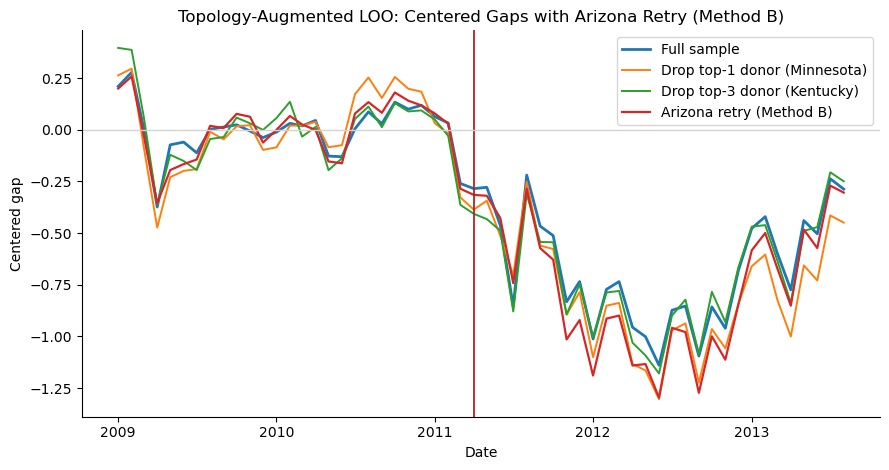

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

full_df = paths_for_plot["full_sample"].copy()
drop1_df = paths_for_plot["drop_top_1_MINNESOTA"].copy()
drop3_df = paths_for_plot["drop_top_3_KENTUCKY"].copy()

az_b_df = pd.read_csv(OUTPUT_DIR / "retryB_continuation_0.5_1.0_2.0_paths.csv")

for df in [full_df, drop1_df, drop3_df, az_b_df]:
    df["date"] = pd.to_datetime(df["date"])

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    full_df["date"],
    full_df["gap_centered_topology_augmented"],
    linewidth=2.0,
    label="Full sample"
)

ax.plot(
    drop1_df["date"],
    drop1_df["gap_centered_topology_augmented"],
    linewidth=1.4,
    label="Drop top-1 donor (Minnesota)"
)

ax.plot(
    drop3_df["date"],
    drop3_df["gap_centered_topology_augmented"],
    linewidth=1.4,
    label="Drop top-3 donor (Kentucky)"
)

ax.plot(
    az_b_df["date"],
    az_b_df["gap_centered_topology_augmented"],
    linewidth=1.6,
    label="Arizona retry (Method B)"
)

ax.axvline(TREATMENT_START, color="firebrick", linewidth=1.3)
ax.axhline(0, color="lightgray", linewidth=1.0)
ax.set_xlabel("Date")
ax.set_ylabel("Centered gap")
ax.set_title("Topology-Augmented LOO: Centered Gaps with Arizona Retry (Method B)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "topology_augmented_loo_centered_gaps_with_arizona_retryB.pdf",
    bbox_inches="tight"
)
plt.show()